# Image Unimodal — Facial Emotion Recognition on MELD face crops

This notebook trains **two CNN classifiers** on the face crops that were extracted from MELD
by `extract_images_from_meld.ipynb` (5 top-scoring face frames per utterance, selected with
EmotiEffLib + MTCNN). The two models share the exact same training pipeline so the comparison
between them is fair:

| Role  | Architecture         | Why                                                            |
|-------|----------------------|----------------------------------------------------------------|
| Big   | **ConvNeXt-Tiny**    | Modern strong CNN (~28M params), excellent ImageNet features, pure conv so Grad-CAM works cleanly. |
| Small | **MobileNetV3-Small**| Mobile/efficient CNN (~2.5M params, ~60 MFLOPs at 224). Same XAI story (conv-based). |

**What this notebook delivers (matches the thesis requirements):**

1. **Accuracy / F1 focused training** — class-weighted cross-entropy, cosine LR with warmup,
   RandAugment, Mixup, AMP, and best-checkpoint selection driven by **weighted F1** on the
   dev split (weighted F1 is preferred to accuracy on MELD because the dataset is heavily
   skewed towards *Neutral*).
2. **Per-frame training + utterance-level evaluation** — the 5 frames per utterance are
   treated as independent samples during training, but at evaluation we *also* aggregate the
   5 softmax vectors into a single utterance-level prediction (closer to the thesis metric).
3. **EcoAI** — for each model we log param count, FLOPs, training wall-clock time per epoch,
   total training time, inference throughput (images / sec), and an optional CodeCarbon
   tracker for real energy/CO2 numbers.
4. **XAI / Grad-CAM** — we visualise where each model attends on a handful of test faces,
   using a tiny self-contained Grad-CAM implementation (no extra dependency needed).
5. **Confusion matrix + classification report** on the test split for both models.

> The frame extraction is imperfect right now (low-resolution ~73×100 crops, sometimes the
> wrong speaker in multi-speaker frames). This notebook does not try to fix that upstream;
> it just consumes whatever `metadata_{split}.csv` points at, so when you rebuild the dataset
> the exact same notebook keeps working.

## 1. Setup — imports, reproducibility, device

Run the pip cell once (commented by default) if any of these packages are missing.
CodeCarbon is optional — if it fails to import we just skip the energy tracker.

In [2]:

!pip install -q codecarbon  
!pip install -q fvcore      

In [1]:
import os
import json
import math
import time
import random
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Tuple, Dict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision import transforms
from torchvision.models import (
    convnext_tiny, ConvNeXt_Tiny_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
)

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility — we don't force full determinism (too slow) but we fix seeds.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available(),
      "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True  # faster for fixed input sizes

e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.7.1+cu118 | cuda available: True | device: cuda
gpu: NVIDIA GeForce RTX 3060


## 2. Configuration

All tunable knobs live here. The defaults match the **Heavy / thorough** training budget you
picked — 50 epochs, 224×224 for the big model, 192×192 for the small one, Mixup on.

The metadata CSVs' `image_path` column contains a **stale** absolute-ish path (Windows
backslashes, points at the original extraction run folder). We intentionally **ignore that
column** and reconstruct the path from `Code/ → ../Data/processed_meld_emotieff/<split>_v1/images/<split>/<basename>`,
which is where the images actually live on disk.

In [2]:
# ---------------- Paths ---------------- #
# This notebook lives in .../Multimodal-Emotion-Recognition---Bachelor-Thesis/Code/ so all
# paths are relative to that Code/ directory (consistent with the other notebooks).
PROJECT_ROOT   = Path("..").resolve()
DATA_ROOT      = PROJECT_ROOT / "Data" / "processed_meld_emotieff"

SPLIT_DIRS = {
    "train": DATA_ROOT / "train_v1",
    "dev":   DATA_ROOT / "dev_v1",
    "test":  DATA_ROOT / "test_v1",
}
# Metadata CSV per split.
META_CSV = {s: d / f"metadata_{s}.csv" for s, d in SPLIT_DIRS.items()}
# Actual image folder per split (ignoring the stale `image_path` column).
IMG_DIR = {s: d / "images" / s for s, d in SPLIT_DIRS.items()}

# Where to save checkpoints, metrics, confusion matrices, Grad-CAM figures, etc.
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments" / "image_unimodal"
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = PROJECT_ROOT / "Models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
for s in ["train", "dev", "test"]:
    print(f"  [{s}] csv exists={META_CSV[s].exists()} | img dir exists={IMG_DIR[s].exists()}")
print("Experiments dir:", EXPERIMENTS_DIR)
print("Models dir:      ", MODELS_DIR)

Project root: E:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis
  [train] csv exists=True | img dir exists=True
  [dev] csv exists=True | img dir exists=True
  [test] csv exists=True | img dir exists=True
Experiments dir: E:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\experiments\image_unimodal
Models dir:       E:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\Models


In [3]:
# ---------------- Label space ---------------- #
# MELD has 7 emotions. Order matches what extract_images_from_meld.ipynb writes out.
CLASSES = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASSES)

# ImageNet mean/std — used for every pretrained model in torchvision.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [4]:
# ---------------- Training configuration ---------------- #
@dataclass
class TrainConfig:
    name: str                 # short identifier used for checkpoint filename
    img_size: int             # input resolution (square)
    batch_size: int
    epochs: int
    lr: float                 # peak LR (after warmup)
    weight_decay: float
    warmup_epochs: int
    label_smoothing: float
    mixup_alpha: float        # 0 disables mixup
    num_workers: int
    use_amp: bool             # mixed precision

# Big model — ConvNeXt-Tiny. Slightly lower LR because it's bigger and pretrained.
CFG_BIG = TrainConfig(
    name="convnext_tiny",
    img_size=224,
    batch_size=64,
    epochs=50,
    lr=1.5e-4,
    weight_decay=0.05,
    warmup_epochs=3,
    label_smoothing=0.1,
    mixup_alpha=0.2,
    # num_workers=4,
    num_workers=0,
    use_amp=True,
)

# Small model — MobileNetV3-Small. Higher LR (common with mobilenets) and higher batch size.
CFG_SMALL = TrainConfig(
    name="mobilenetv3_small",
    img_size=192,
    batch_size=128,
    epochs=50,
    lr=5e-4,
    weight_decay=1e-4,
    warmup_epochs=3,
    label_smoothing=0.1,
    mixup_alpha=0.2,
    # num_workers=4,
    num_workers=0,
    use_amp=True,
)

# The evaluation image size is decoupled from the training one — both models are evaluated
# at their training resolution (no test-time multi-scale, keeps things fair).

print("Big   config:", CFG_BIG)
print("Small config:", CFG_SMALL)

Big   config: TrainConfig(name='convnext_tiny', img_size=224, batch_size=64, epochs=50, lr=0.00015, weight_decay=0.05, warmup_epochs=3, label_smoothing=0.1, mixup_alpha=0.2, num_workers=0, use_amp=True)
Small config: TrainConfig(name='mobilenetv3_small', img_size=192, batch_size=128, epochs=50, lr=0.0005, weight_decay=0.0001, warmup_epochs=3, label_smoothing=0.1, mixup_alpha=0.2, num_workers=0, use_amp=True)


## 3. Data — metadata loading, class weights, Dataset

We drop any rows with `status != "ok"` (utterances for which the extractor didn't find a
face or the video was missing) and we compute inverse-frequency class weights from the
training metadata for the weighted cross-entropy loss.

In [5]:
def load_metadata(split: str) -> pd.DataFrame:
    """Load metadata for a split, filter to usable rows, and resolve real image paths."""
    df = pd.read_csv(META_CSV[split])
    # Keep only rows that the extractor marked as successful.
    df = df[df["status"] == "ok"].copy()
    # Drop anything whose label isn't in our canonical list (shouldn't happen, but safe).
    df = df[df["emotion_norm"].isin(CLASSES)].copy()
    # Integer class index — what the model predicts.
    df["label_idx"] = df["emotion_norm"].map(CLASS_TO_IDX).astype(np.int64)
    # The `image_path` column from the CSV is stale / uses Windows backslashes and often
    # points at the original extraction run folder. We rebuild the path from the basename.
    def _basename(p: str) -> str:
        return os.path.basename(str(p).replace("\\", "/"))
    df["image_basename"] = df["image_path"].apply(_basename)
    df["image_abspath"] = df["image_basename"].apply(lambda n: str(IMG_DIR[split] / n))
    return df.reset_index(drop=True)

df_train = load_metadata("train")
df_dev   = load_metadata("dev")
df_test  = load_metadata("test")

print(f"train frames: {len(df_train):>6}   utterances: {df_train.groupby(['dialogue_id','utterance_id']).ngroups:>5}")
print(f"dev   frames: {len(df_dev):>6}   utterances: {df_dev.groupby(['dialogue_id','utterance_id']).ngroups:>5}")
print(f"test  frames: {len(df_test):>6}   utterances: {df_test.groupby(['dialogue_id','utterance_id']).ngroups:>5}")

print("\nPer-class distribution (train):")
print(df_train["emotion_norm"].value_counts().reindex(CLASSES))

train frames:  48980   utterances:  9966
dev   frames:   5413   utterances:  1104
test  frames:  12772   utterances:  2607

Per-class distribution (train):
emotion_norm
Anger         5438
Disgust       1345
Fear          1323
Happiness     8511
Neutral      23071
Sadness       3390
Surprise      5902
Name: count, dtype: int64


In [6]:
# Quick sanity check — grab 1 image from each split and confirm the file exists.
for split, df in [("train", df_train), ("dev", df_dev), ("test", df_test)]:
    p = Path(df["image_abspath"].iloc[0])
    print(f"[{split}] sample:", p, "| exists:", p.exists())

[train] sample: E:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\Data\processed_meld_emotieff\train_v1\images\train\dia0_utt0_r0_f00009_gtp0449.jpg | exists: True
[dev] sample: E:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\Data\processed_meld_emotieff\dev_v1\images\dev\dia0_utt0_r0_f00018_gtp0598.jpg | exists: True
[test] sample: E:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\Data\processed_meld_emotieff\test_v1\images\test\dia0_utt0_r0_f00024_gtp0062.jpg | exists: True


In [7]:
# Inverse-frequency class weights for the loss. We normalise so they average to 1.0 —
# that keeps the loss magnitude comparable to an unweighted run.
counts = df_train["label_idx"].value_counts().reindex(range(NUM_CLASSES)).astype(float)
inv = 1.0 / counts
class_weights = (inv / inv.mean()).values.astype(np.float32)
class_weights_t = torch.tensor(class_weights, device=DEVICE, dtype=torch.float32)

print("class  count   weight")
for i, c in enumerate(CLASSES):
    print(f"  {c:10s} {int(counts[i]):6d}   {class_weights[i]:.3f}")

class  count   weight
  Anger        5438   0.558
  Disgust      1345   2.254
  Fear         1323   2.292
  Happiness    8511   0.356
  Neutral     23071   0.131
  Sadness      3390   0.894
  Surprise     5902   0.514


In [8]:
# # ---------------- Dataset ---------------- #
# class MELDFaceDataset(Dataset):
#     """Per-frame MELD face dataset.

#     Returns:
#         img      : transformed tensor (C,H,W)
#         label    : int64 class index
#         meta_idx : row index in the underlying DataFrame (used for utterance-level aggregation)
#     """
#     def __init__(self, df: pd.DataFrame, transform):
#         # Reset the DataFrame index so meta_idx equals row position.
#         self.df = df.reset_index(drop=True)
#         self.transform = transform
#         self.paths  = self.df["image_abspath"].values
#         self.labels = self.df["label_idx"].values

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, i):
#         # Open as RGB — the extracted JPGs are already face crops.
#         img = Image.open(self.paths[i]).convert("RGB")
#         img = self.transform(img)
#         return img, int(self.labels[i]), int(i)

# ---------GPT
class MELDFaceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform, cache_ram: bool = True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.paths = self.df["image_abspath"].values
        self.labels = self.df["label_idx"].values
        self.cache_ram = cache_ram

        # Stores decoded RGB PIL images before transforms.
        self._cache = [None] * len(self.paths) if cache_ram else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        if self.cache_ram:
            img = self._cache[i]

            if img is None:
                img = Image.open(self.paths[i]).convert("RGB")
                self._cache[i] = img
            else:
                img = img.copy()
        else:
            img = Image.open(self.paths[i]).convert("RGB")

        img = self.transform(img)
        return img, int(self.labels[i]), int(i)

In [9]:
# ---------------- Transforms ---------------- #
# Training augmentations: the face crops are ~73x100, so we upsample via bilinear, jitter
# colour / hue to be robust to different lighting, and apply RandAugment (moderate magnitude).
# For the small model we use slightly weaker aug to avoid underfitting.

def build_transforms(img_size: int, augment: bool, strong_augment: bool = True):
    if augment:
        tf = transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32),
                              interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            # RandAugment is a strong modern aug — ops chosen randomly, magnitude controlled.
            transforms.RandAugment(num_ops=2, magnitude=7 if strong_augment else 5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),  # occlusion simulation
        ])
    else:
        tf = transforms.Compose([
            transforms.Resize((img_size, img_size),
                              interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return tf

In [10]:
# def build_loaders(cfg: TrainConfig):
#     tr_tf = build_transforms(cfg.img_size, augment=True,
#                              strong_augment=(cfg.name != "mobilenetv3_small"))
#     ev_tf = build_transforms(cfg.img_size, augment=False)

#     ds_train = MELDFaceDataset(df_train, tr_tf)
#     ds_dev   = MELDFaceDataset(df_dev,   ev_tf)
#     ds_test  = MELDFaceDataset(df_test,  ev_tf)

#     # pin_memory helps throughput on GPU; persistent_workers avoids worker respawn overhead.
#     common_kwargs = dict(
#         num_workers=cfg.num_workers, pin_memory=(DEVICE.type == "cuda"),
#         persistent_workers=(cfg.num_workers > 0),
#     )
#     dl_train = DataLoader(ds_train, batch_size=cfg.batch_size, shuffle=True,
#                           drop_last=True, **common_kwargs)
#     dl_dev   = DataLoader(ds_dev,   batch_size=cfg.batch_size, shuffle=False, **common_kwargs)
#     dl_test  = DataLoader(ds_test,  batch_size=cfg.batch_size, shuffle=False, **common_kwargs)
#     return dl_train, dl_dev, dl_test
# -------GPT
def build_loaders(cfg: TrainConfig, cache_ram: bool = True):
    tr_tf = build_transforms(
        cfg.img_size,
        augment=True,
        strong_augment=(cfg.name != "mobilenetv3_small")
    )
    ev_tf = build_transforms(cfg.img_size, augment=False)

    ds_train = MELDFaceDataset(df_train, tr_tf, cache_ram=cache_ram)
    ds_dev   = MELDFaceDataset(df_dev,   ev_tf, cache_ram=cache_ram)
    ds_test  = MELDFaceDataset(df_test,  ev_tf, cache_ram=cache_ram)

    common_kwargs = dict(
        num_workers=cfg.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(cfg.num_workers > 0),
    )

    dl_train = DataLoader(
        ds_train,
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=True,
        **common_kwargs
    )

    dl_dev = DataLoader(
        ds_dev,
        batch_size=cfg.batch_size,
        shuffle=False,
        **common_kwargs
    )

    dl_test = DataLoader(
        ds_test,
        batch_size=cfg.batch_size,
        shuffle=False,
        **common_kwargs
    )

    return dl_train, dl_dev, dl_test

## 4. Models

Both models start from ImageNet pretrained weights and have their classifier head replaced
with a 7-way `Linear`. We also wire a `cam_target_layer` attribute to the module we want
Grad-CAM to hook — the last conv block in each backbone.

In [11]:
def build_big_model(num_classes: int = NUM_CLASSES) -> nn.Module:
    """ConvNeXt-Tiny, ImageNet-pretrained. ~28M params."""
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = convnext_tiny(weights=weights)
    # torchvision's classifier is: LayerNorm -> Flatten -> Linear(768, 1000).
    # We replace only the final Linear to keep the normalisation.
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    # Grad-CAM target: the last ConvNeXt block's conv output (features[-1] is a Sequential of
    # CNBlocks, and the last CNBlock's `block[0]` is the 7x7 depthwise conv).
    model.cam_target_layer = model.features[-1][-1]
    return model


def build_small_model(num_classes: int = NUM_CLASSES) -> nn.Module:
    """MobileNetV3-Small, ImageNet-pretrained. ~2.5M params."""
    weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = mobilenet_v3_small(weights=weights)
    # Classifier: Linear(576, 1024) -> Hardswish -> Dropout -> Linear(1024, 1000)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    # Grad-CAM target: last InvertedResidual block (model.features[-1]).
    model.cam_target_layer = model.features[-1]
    return model

## 5. Training utilities

The one function worth knowing about: `mixup_data` mixes two random images and their
labels in a batch. This regularises the model and typically helps F1 on imbalanced
datasets. It only runs on the training loader.

`WarmupCosineLR` linearly ramps the LR from 0 to `lr` over `warmup_epochs`, then cosine-
decays to 0 over the rest of training.

In [12]:
def mixup_data(x: torch.Tensor, y: torch.Tensor, alpha: float):
    """Returns mixed x, (y_a, y_b, lam) — the loss is computed as
    lam * CE(logits, y_a) + (1-lam) * CE(logits, y_b)."""
    if alpha <= 0:
        return x, (y, y, 1.0)
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)  # skew towards the "original" sample — stabler training
    perm = torch.randperm(x.size(0), device=x.device)
    mixed = lam * x + (1 - lam) * x[perm]
    return mixed, (y, y[perm], float(lam))


def mixup_criterion(logits, y_a, y_b, lam, base_criterion):
    return lam * base_criterion(logits, y_a) + (1 - lam) * base_criterion(logits, y_b)

In [13]:
class WarmupCosineLR(torch.optim.lr_scheduler._LRScheduler):
    """Linear warmup for `warmup_steps` then cosine decay to 0 over the rest."""
    def __init__(self, optimizer, warmup_steps: int, total_steps: int, last_epoch: int = -1):
        self.warmup_steps = max(1, warmup_steps)
        self.total_steps  = max(warmup_steps + 1, total_steps)
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch + 1  # 1-indexed
        if step <= self.warmup_steps:
            scale = step / self.warmup_steps
        else:
            prog  = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            scale = 0.5 * (1 + math.cos(math.pi * prog))
        return [base_lr * scale for base_lr in self.base_lrs]

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion=None) -> Dict[str, float]:
    """Returns per-frame metrics + loss. Labels and preds stored for confusion matrices."""
    model.eval()
    all_preds, all_labels, all_probs, all_idx = [], [], [], []
    total_loss, total_n = 0.0, 0
    for x, y, idx in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        if criterion is not None:
            total_loss += criterion(logits, y).item() * x.size(0)
            total_n    += x.size(0)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_idx.append(idx.numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    probs  = np.concatenate(all_probs)
    idxs   = np.concatenate(all_idx)
    return {
        "loss":         (total_loss / max(1, total_n)) if criterion is not None else float("nan"),
        "accuracy":     accuracy_score(labels, preds),
        "f1_weighted":  f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro":     f1_score(labels, preds, average="macro",    zero_division=0),
        "preds": preds, "labels": labels, "probs": probs, "idxs": idxs,
    }

In [15]:
def train_one_model(
    model: nn.Module, cfg: TrainConfig,
    dl_train: DataLoader, dl_dev: DataLoader,
    ckpt_path: Path,
) -> Dict:
    """Train `model` with the config, saving the best checkpoint by dev weighted-F1.

    Returns a dict with the history, best metrics, and wall-clock timings.
    """
    model = model.to(DEVICE)

    # Weighted CE loss — class_weights_t was computed above from training frequencies.
    # label_smoothing reduces overconfidence; works alongside mixup.
    criterion = nn.CrossEntropyLoss(weight=class_weights_t,
                                    label_smoothing=cfg.label_smoothing)
    # For evaluation we use unweighted + no smoothing so the "loss" number is interpretable.
    eval_criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr,
                                  weight_decay=cfg.weight_decay)
    steps_per_epoch = len(dl_train)
    scheduler = WarmupCosineLR(
        optimizer,
        warmup_steps=cfg.warmup_epochs * steps_per_epoch,
        total_steps =cfg.epochs        * steps_per_epoch,
    )
    scaler = GradScaler(enabled=cfg.use_amp and DEVICE.type == "cuda")

    history = {"train_loss": [], "dev_loss": [], "dev_acc": [],
               "dev_f1_weighted": [], "dev_f1_macro": [], "epoch_time_s": []}
    best = {"f1_weighted": -1.0, "epoch": -1}
    train_total_start = time.time()

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0 = time.time()
        running_loss, running_n = 0.0, 0
        pbar = tqdm(dl_train, desc=f"[{cfg.name}] epoch {epoch:02d}/{cfg.epochs}",
                    leave=False)
        for x, y, _ in pbar:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            # Mixup (on the raw tensors; mean/std normalisation already happened in the loader).
            x_mix, (y_a, y_b, lam) = mixup_data(x, y, cfg.mixup_alpha)

            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):
                logits = model(x_mix)
                loss = mixup_criterion(logits, y_a, y_b, lam, criterion)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item() * x.size(0)
            running_n    += x.size(0)
            pbar.set_postfix(loss=f"{running_loss/max(1,running_n):.4f}",
                             lr=f"{optimizer.param_groups[0]['lr']:.2e}")

        train_loss = running_loss / max(1, running_n)
        epoch_time = time.time() - t0

        dev = evaluate(model, dl_dev, criterion=eval_criterion)

        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev["loss"])
        history["dev_acc"].append(dev["accuracy"])
        history["dev_f1_weighted"].append(dev["f1_weighted"])
        history["dev_f1_macro"].append(dev["f1_macro"])
        history["epoch_time_s"].append(epoch_time)

        # --- Best-ckpt by weighted F1 (better than accuracy on MELD, as agreed) ---
        improved = dev["f1_weighted"] > best["f1_weighted"]
        print(f"[{cfg.name}] ep {epoch:02d} | train_loss {train_loss:.4f} | "
              f"dev_loss {dev['loss']:.4f} | acc {dev['accuracy']:.4f} | "
              f"f1_w {dev['f1_weighted']:.4f} | f1_m {dev['f1_macro']:.4f} | "
              f"time {epoch_time:.1f}s {'<-- new best' if improved else ''}")

        if improved:
            best = {
                "f1_weighted": dev["f1_weighted"], "f1_macro": dev["f1_macro"],
                "accuracy": dev["accuracy"], "epoch": epoch,
            }
            torch.save({
                "model_state_dict":  model.state_dict(),
                "cfg": asdict(cfg),
                "classes": CLASSES,
                "dev_metrics": {k: v for k, v in dev.items()
                                if k not in ("preds", "labels", "probs", "idxs")},
                "epoch": epoch,
            }, ckpt_path)

    total_train_time = time.time() - train_total_start
    return {
        "history": history, "best": best,
        "total_train_time_s": total_train_time,
        "avg_epoch_time_s": float(np.mean(history["epoch_time_s"])),
        "ckpt_path": str(ckpt_path),
    }

## 6. EcoAI utilities

We report **four** efficiency numbers per model:

1. **Params** — total trainable parameters.
2. **FLOPs** — we use `fvcore` if installed, otherwise a simple fallback (conv + linear).
3. **Training time** — total wall clock + average per epoch (collected during training).
4. **Inference throughput** — images / second on a timed pass over the test loader.

If you have `codecarbon` installed, we also wrap each training run in an `EmissionsTracker`
to get real kWh / kg-CO2 estimates. It's all-or-nothing: we no-op if the import fails.

In [16]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def estimate_flops(model: nn.Module, img_size: int) -> Optional[float]:
    """Try fvcore first (most accurate), fall back to None if unavailable."""
    try:
        from fvcore.nn import FlopCountAnalysis
        model.eval()
        dummy = torch.zeros(1, 3, img_size, img_size, device=next(model.parameters()).device)
        with torch.no_grad():
            flops = FlopCountAnalysis(model, dummy).unsupported_ops_warnings(False).uncalled_modules_warnings(False)
            return float(flops.total())
    except Exception as e:
        print(f"  [flops] fvcore unavailable ({e.__class__.__name__}); skipping FLOPs.")
        return None


@torch.no_grad()
def measure_inference_throughput(model: nn.Module, loader: DataLoader,
                                 n_warmup_batches: int = 5) -> float:
    """Images/second on the given loader. Warms up a few batches first."""
    model.eval()
    it = iter(loader)
    for _ in range(n_warmup_batches):
        try:
            x, _, _ = next(it)
        except StopIteration:
            break
        model(x.to(DEVICE, non_blocking=True))
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    n_imgs, t0 = 0, time.time()
    for x, _, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        _ = model(x)
        n_imgs += x.size(0)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return n_imgs / (time.time() - t0)

In [17]:
# Optional CodeCarbon hookup.
try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
    print("codecarbon available — real energy/CO2 numbers will be logged.")
except Exception:
    EmissionsTracker = None
    CODECARBON_AVAILABLE = False
    print("codecarbon not installed — EcoAI will report time/FLOPs only.")


def run_with_carbon_tracking(run_name: str, fn, *args, **kwargs):
    """Runs `fn(*args, **kwargs)`. If codecarbon is present, wraps it in an EmissionsTracker.
    Returns (result, emissions_dict_or_None)."""
    if not CODECARBON_AVAILABLE:
        return fn(*args, **kwargs), None
    tracker = EmissionsTracker(project_name=run_name,
                               output_dir=str(EXPERIMENTS_DIR),
                               log_level="error")
    tracker.start()
    try:
        result = fn(*args, **kwargs)
    finally:
        emissions_kg = tracker.stop()
    data = tracker.final_emissions_data if hasattr(tracker, "final_emissions_data") else None
    info = {"emissions_kg_co2": float(emissions_kg) if emissions_kg is not None else None}
    if data is not None:
        info.update({
            "energy_kwh":     getattr(data, "energy_consumed", None),
            "duration_s":     getattr(data, "duration", None),
            "cpu_power_w":    getattr(data, "cpu_power", None),
            "gpu_power_w":    getattr(data, "gpu_power", None),
        })
    return result, info

codecarbon available — real energy/CO2 numbers will be logged.


## 7. Train the big model — ConvNeXt-Tiny

This is the long-running cell. On a single RTX-class GPU at 224×224 / batch 64, expect
roughly 10–20 minutes per epoch depending on disk speed. The best checkpoint is saved to
`Models/best_image_convnext_tiny.pth` whenever dev weighted-F1 improves.

In [23]:
dl_train_big, dl_dev_big, dl_test_big = build_loaders(CFG_BIG)
model_big = build_big_model()
ckpt_big  = MODELS_DIR / f"best_image_{CFG_BIG.name}.pth"

print(f"Big model params: {count_params(model_big):,}")
print(f"Training steps/epoch: {len(dl_train_big)} | batch size: {CFG_BIG.batch_size}")

Big model params: 27,825,511
Training steps/epoch: 765 | batch size: 64


In [66]:
big_run, big_emissions = run_with_carbon_tracking(
    f"image_unimodal_{CFG_BIG.name}",
    train_one_model, model_big, CFG_BIG, dl_train_big, dl_dev_big, ckpt_big,
)
print("\n=== Big model training finished ===")
print(f"best dev F1 (weighted): {big_run['best']['f1_weighted']:.4f} at epoch {big_run['best']['epoch']}")
print(f"total train time: {big_run['total_train_time_s']/60:.1f} min")
if big_emissions:
    print(f"codecarbon: {big_emissions}")

C:\Users\Andrei\AppData\Local\Temp\ipykernel_4412\253054413.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.use_amp and DEVICE.type == "cuda")
[convnext_tiny] epoch 01/50:   0%|          | 0/765 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_4412\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


[convnext_tiny] ep 01 | train_loss 2.1818 | dev_loss 2.0364 | acc 0.1201 | f1_w 0.1091 | f1_m 0.1274 | time 539.9s <-- new best


[convnext_tiny] epoch 02/50:   0%|          | 0/765 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_4412\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


[convnext_tiny] ep 02 | train_loss 2.1052 | dev_loss 1.9600 | acc 0.1454 | f1_w 0.1472 | f1_m 0.1507 | time 517.7s <-- new best


[convnext_tiny] epoch 03/50:   0%|          | 0/765 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_4412\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


...

[convnext_tiny] ep 10 | train_loss 1.5893 | dev_loss 1.9176 | acc 0.3041 | f1_w 0.3267 | f1_m 0.2433 | time 497.6s 


[convnext_tiny] epoch 11/50:   0%|          | 0/765 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_4412\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


[convnext_tiny] ep 11 | train_loss 1.5397 | dev_loss 1.9521 | acc 0.3028 | f1_w 0.3183 | f1_m 0.2444 | time 505.2s 


[convnext_tiny] epoch 12/50:   0%|          | 0/765 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_4412\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


KeyboardInterrupt: 

## 8. Train the small model — MobileNetV3-Small

Same recipe, smaller model, higher LR, smaller inputs. Much faster per epoch — the goal
is to see how close we can get to the big model for a fraction of the compute.

In [18]:
dl_train_sm, dl_dev_sm, dl_test_sm = build_loaders(CFG_SMALL)
model_small = build_small_model()
ckpt_small  = MODELS_DIR / f"best_image_{CFG_SMALL.name}.pth"

print(f"Small model params: {count_params(model_small):,}")
print(f"Training steps/epoch: {len(dl_train_sm)} | batch size: {CFG_SMALL.batch_size}")

Small model params: 1,525,031
Training steps/epoch: 382 | batch size: 128


In [19]:
small_run, small_emissions = run_with_carbon_tracking(
    f"image_unimodal_{CFG_SMALL.name}",
    train_one_model, model_small, CFG_SMALL, dl_train_sm, dl_dev_sm, ckpt_small,
)
print("\n=== Small model training finished ===")
print(f"best dev F1 (weighted): {small_run['best']['f1_weighted']:.4f} at epoch {small_run['best']['epoch']}")
print(f"total train time: {small_run['total_train_time_s']/60:.1f} min")
if small_emissions:
    print(f"codecarbon: {small_emissions}")

[codecarbon WARNING @ 15:53:27] Multiple instances of codecarbon are allowed to run at the same time.
C:\Users\Andrei\AppData\Local\Temp\ipykernel_7984\253054413.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.use_amp and DEVICE.type == "cuda")
[mobilenetv3_small] epoch 01/50:   0%|          | 0/382 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_7984\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


[mobilenetv3_small] ep 01 | train_loss 2.2053 | dev_loss 1.9731 | acc 0.1245 | f1_w 0.1275 | f1_m 0.1111 | time 599.4s <-- new best


[mobilenetv3_small] epoch 02/50:   0%|          | 0/382 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_7984\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


[mobilenetv3_small] ep 02 | train_loss 2.1470 | dev_loss 1.9515 | acc 0.1459 | f1_w 0.1687 | f1_m 0.1397 | time 298.4s <-- new best


[mobilenetv3_small] epoch 03/50:   0%|          | 0/382 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_7984\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


...

[mobilenetv3_small] ep 48 | train_loss 1.3226 | dev_loss 1.8919 | acc 0.3266 | f1_w 0.3436 | f1_m 0.2368 | time 303.8s 


[mobilenetv3_small] epoch 49/50:   0%|          | 0/382 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_7984\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


[mobilenetv3_small] ep 49 | train_loss 1.3335 | dev_loss 1.8902 | acc 0.3264 | f1_w 0.3433 | f1_m 0.2368 | time 295.1s 


[mobilenetv3_small] epoch 50/50:   0%|          | 0/382 [00:00<?, ?it/s]C:\Users\Andrei\AppData\Local\Temp\ipykernel_7984\253054413.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.use_amp and DEVICE.type == "cuda"):


[mobilenetv3_small] ep 50 | train_loss 1.2806 | dev_loss 1.8920 | acc 0.3244 | f1_w 0.3414 | f1_m 0.2361 | time 295.4s 

=== Small model training finished ===
best dev F1 (weighted): 0.3518 at epoch 34
total train time: 259.7 min
codecarbon: {'emissions_kg_co2': 0.07277008141660304, 'energy_kwh': 0.3024739130221298, 'duration_s': 15584.948738599996, 'cpu_power_w': 12.720022075551324, 'gpu_power_w': 38.262420768795394}


## 9. Training curves

In [20]:
def plot_history(hist_big, hist_small, out_path: Path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    for ax, key, title in [
        (axes[0], "train_loss",    "Train loss"),
        (axes[1], "dev_f1_weighted", "Dev weighted F1"),
        (axes[2], "dev_acc",       "Dev accuracy"),
    ]:
        ax.plot(hist_big[key],   label="ConvNeXt-Tiny",     linewidth=2)
        ax.plot(hist_small[key], label="MobileNetV3-Small", linewidth=2)
        ax.set_title(title); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

plot_history(big_run["history"], small_run["history"],
             EXPERIMENTS_DIR / "training_curves.png")

NameError: name 'big_run' is not defined

## 10. Evaluation on test — per-frame + utterance-level

Per-frame evaluation is the straight classification. For utterance-level we average the 5
softmax vectors for the same `(dialogue_id, utterance_id)` and take argmax — this is the
number most directly comparable to the audio pipeline.

In [21]:
def load_ckpt_into(model: nn.Module, ckpt_path: Path) -> Dict:
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE).eval()
    return ckpt


def utterance_level_metrics(eval_out: Dict, df: pd.DataFrame) -> Dict[str, float]:
    """Aggregate 5 frame-level softmax vectors per utterance into a single prediction."""
    idxs  = eval_out["idxs"]
    probs = eval_out["probs"]
    # df rows corresponding to each returned idx (the DataLoader is shuffle=False at eval).
    utt_keys = df.iloc[idxs][["dialogue_id", "utterance_id"]].apply(tuple, axis=1).values
    utt_labels = df.iloc[idxs]["label_idx"].values

    # Group: for each utterance, average probs and take the majority true label
    # (all 5 frames share the same label anyway).
    buckets: Dict[Tuple[int,int], List[np.ndarray]] = {}
    bucket_labels: Dict[Tuple[int,int], int] = {}
    for key, p, y in zip(utt_keys, probs, utt_labels):
        buckets.setdefault(key, []).append(p)
        bucket_labels[key] = int(y)

    utt_pred, utt_true = [], []
    for key, probs_list in buckets.items():
        avg = np.mean(np.stack(probs_list, axis=0), axis=0)
        utt_pred.append(int(avg.argmax()))
        utt_true.append(bucket_labels[key])
    utt_pred = np.asarray(utt_pred); utt_true = np.asarray(utt_true)
    return {
        "accuracy":    accuracy_score(utt_true, utt_pred),
        "f1_weighted": f1_score(utt_true, utt_pred, average="weighted", zero_division=0),
        "f1_macro":    f1_score(utt_true, utt_pred, average="macro",    zero_division=0),
        "preds": utt_pred, "labels": utt_true,
    }

In [24]:
# --- Big model: reload best + test ---
model_big_best = build_big_model()
big_ckpt = load_ckpt_into(model_big_best, ckpt_big)

# Use a plain eval loader from the big-model config (same img_size as training).
_, _, dl_test_big = build_loaders(CFG_BIG)

big_test_frame = evaluate(model_big_best, dl_test_big)
big_test_utt   = utterance_level_metrics(big_test_frame, df_test)

print("== ConvNeXt-Tiny — test set ==")
print(f"  per-frame       acc {big_test_frame['accuracy']:.4f}  f1_w {big_test_frame['f1_weighted']:.4f}  f1_m {big_test_frame['f1_macro']:.4f}")
print(f"  per-utterance   acc {big_test_utt['accuracy']:.4f}  f1_w {big_test_utt['f1_weighted']:.4f}  f1_m {big_test_utt['f1_macro']:.4f}")

== ConvNeXt-Tiny — test set ==
  per-frame       acc 0.3389  f1_w 0.3623  f1_m 0.2476
  per-utterance   acc 0.3989  f1_w 0.4190  f1_m 0.2889


In [25]:
# --- Small model: reload best + test ---
model_small_best = build_small_model()
small_ckpt = load_ckpt_into(model_small_best, ckpt_small)

_, _, dl_test_sm = build_loaders(CFG_SMALL)

small_test_frame = evaluate(model_small_best, dl_test_sm)
small_test_utt   = utterance_level_metrics(small_test_frame, df_test)

print("== MobileNetV3-Small — test set ==")
print(f"  per-frame       acc {small_test_frame['accuracy']:.4f}  f1_w {small_test_frame['f1_weighted']:.4f}  f1_m {small_test_frame['f1_macro']:.4f}")
print(f"  per-utterance   acc {small_test_utt['accuracy']:.4f}  f1_w {small_test_utt['f1_weighted']:.4f}  f1_m {small_test_utt['f1_macro']:.4f}")

== MobileNetV3-Small — test set ==
  per-frame       acc 0.3285  f1_w 0.3546  f1_m 0.2194
  per-utterance   acc 0.3901  f1_w 0.4125  f1_m 0.2562


## 11. Confusion matrix + classification report

Shown for both models at utterance level (this is the more meaningful number for MELD).

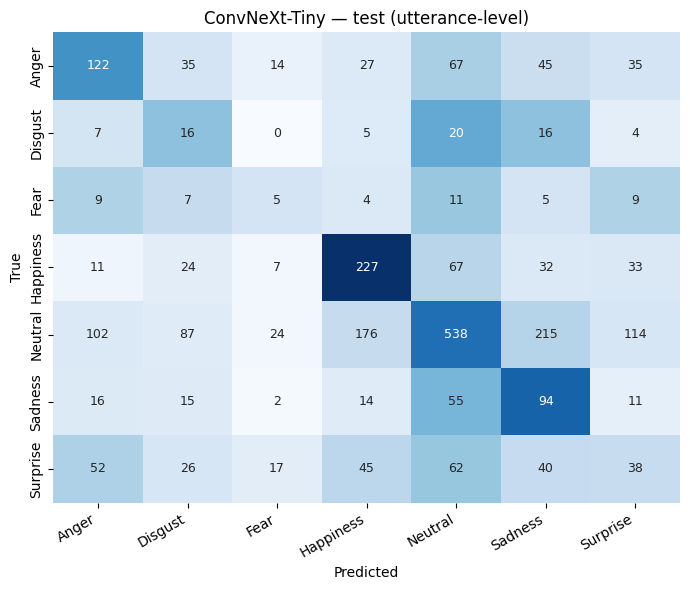

              precision    recall  f1-score   support

       Anger     0.3824    0.3536    0.3675       345
     Disgust     0.0762    0.2353    0.1151        68
        Fear     0.0725    0.1000    0.0840        50
   Happiness     0.4558    0.5661    0.5050       401
     Neutral     0.6561    0.4283    0.5183      1256
     Sadness     0.2103    0.4541    0.2875       207
    Surprise     0.1557    0.1357    0.1450       280

    accuracy                         0.3989      2607
   macro avg     0.2870    0.3247    0.2889      2607
weighted avg     0.4736    0.3989    0.4190      2607



In [26]:
def plot_confusion(y_true, y_pred, title: str, out_path: Path):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False,
                annot_kws={"size": 9})
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.xticks(rotation=30, ha="right"); plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

plot_confusion(big_test_utt["labels"], big_test_utt["preds"],
               "ConvNeXt-Tiny — test (utterance-level)",
               EXPERIMENTS_DIR / "confusion_convnext_tiny_utt.png")
print(classification_report(big_test_utt["labels"], big_test_utt["preds"],
                            target_names=CLASSES, digits=4, zero_division=0))

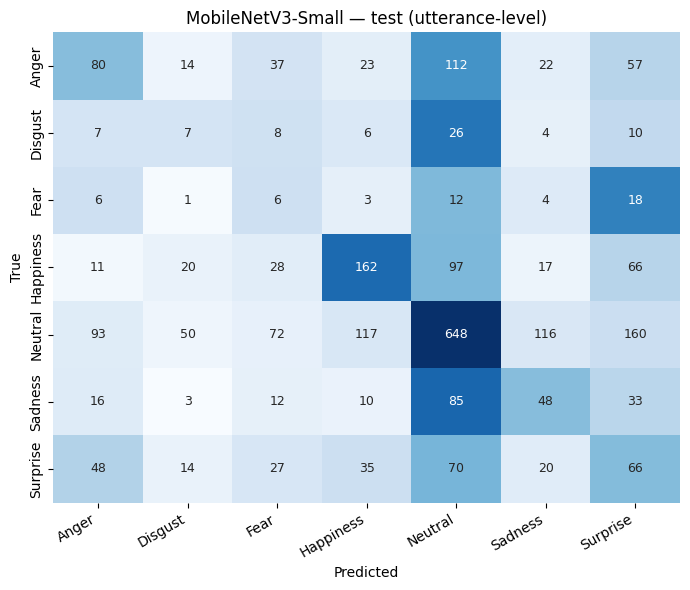

              precision    recall  f1-score   support

       Anger     0.3065    0.2319    0.2640       345
     Disgust     0.0642    0.1029    0.0791        68
        Fear     0.0316    0.1200    0.0500        50
   Happiness     0.4551    0.4040    0.4280       401
     Neutral     0.6171    0.5159    0.5620      1256
     Sadness     0.2078    0.2319    0.2192       207
    Surprise     0.1610    0.2357    0.1913       280

    accuracy                         0.3901      2607
   macro avg     0.2633    0.2632    0.2562      2607
weighted avg     0.4440    0.3901    0.4125      2607



In [27]:
plot_confusion(small_test_utt["labels"], small_test_utt["preds"],
               "MobileNetV3-Small — test (utterance-level)",
               EXPERIMENTS_DIR / "confusion_mobilenetv3_small_utt.png")
print(classification_report(small_test_utt["labels"], small_test_utt["preds"],
                            target_names=CLASSES, digits=4, zero_division=0))

## 12. Grad-CAM — where does the model look?

A lightweight Grad-CAM implementation (forward + backward hooks on `model.cam_target_layer`).
We run it for 2 samples per emotion — enough for the thesis, not so many you drown the
report. Both models use the same samples so the visualisations are directly comparable.

In [28]:
class GradCAM:
    """Minimal Grad-CAM that hooks a single conv-like layer."""
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients   = None
        self._fhandle = target_layer.register_forward_hook(self._save_activation)
        self._bhandle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x: torch.Tensor, class_idx: Optional[int] = None) -> np.ndarray:
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        score = logits[0, class_idx]
        score.backward(retain_graph=False)

        # Weighted channel average of activations.
        grads = self.gradients        # (1, C, h, w)
        acts  = self.activations      # (1, C, h, w)
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=False).squeeze(0)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()

    def close(self):
        self._fhandle.remove()
        self._bhandle.remove()

In [29]:
def overlay_cam_on_image(pil_img: Image.Image, cam: np.ndarray, alpha: float = 0.45):
    """Resize heatmap to image size and blend using matplotlib's jet colormap."""
    import matplotlib.cm as cm
    w, h = pil_img.size
    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8))
                           .resize((w, h), Image.BILINEAR)) / 255.0
    heat = cm.jet(cam_resized)[..., :3]  # drop alpha channel
    base = np.asarray(pil_img).astype(np.float32) / 255.0
    blended = (1 - alpha) * base + alpha * heat
    return np.clip(blended, 0, 1)


def pick_samples(df: pd.DataFrame, n_per_class: int = 2, seed: int = 0) -> pd.DataFrame:
    rng = np.random.RandomState(seed)
    chunks = []
    for c in CLASSES:
        sub = df[df["emotion_norm"] == c]
        if len(sub) == 0:
            continue
        chunks.append(sub.iloc[rng.choice(len(sub), size=min(n_per_class, len(sub)), replace=False)])
    return pd.concat(chunks, ignore_index=True)

In [30]:
def run_gradcam_grid(model: nn.Module, cfg: TrainConfig, samples_df: pd.DataFrame,
                     title: str, out_path: Path):
    """Run Grad-CAM on `samples_df` and save a grid image."""
    model = model.to(DEVICE).eval()
    cam = GradCAM(model, model.cam_target_layer)
    eval_tf = build_transforms(cfg.img_size, augment=False)

    n = len(samples_df)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.2))
    axes = np.atleast_2d(axes).flatten()

    for ax in axes:
        ax.axis("off")

    for i, row in enumerate(samples_df.itertuples(index=False)):
        pil = Image.open(row.image_abspath).convert("RGB")
        x = eval_tf(pil).unsqueeze(0).to(DEVICE)
        # We have to re-enable grads for the CAM's backward pass.
        x.requires_grad_(False)
        heat = cam(x, class_idx=int(row.label_idx))
        # Predicted label too (for the title):
        with torch.no_grad():
            pred = int(model(x).argmax(dim=1).item())
        blended = overlay_cam_on_image(pil.resize((cfg.img_size, cfg.img_size)), heat)

        ax = axes[i]
        ax.imshow(blended)
        ax.set_title(f"gt={row.emotion_norm}\npred={IDX_TO_CLASS[pred]}",
                     fontsize=9,
                     color=("green" if pred == int(row.label_idx) else "red"))
    cam.close()

    fig.suptitle(title, fontsize=12); plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

Grad-CAM on 14 test samples.


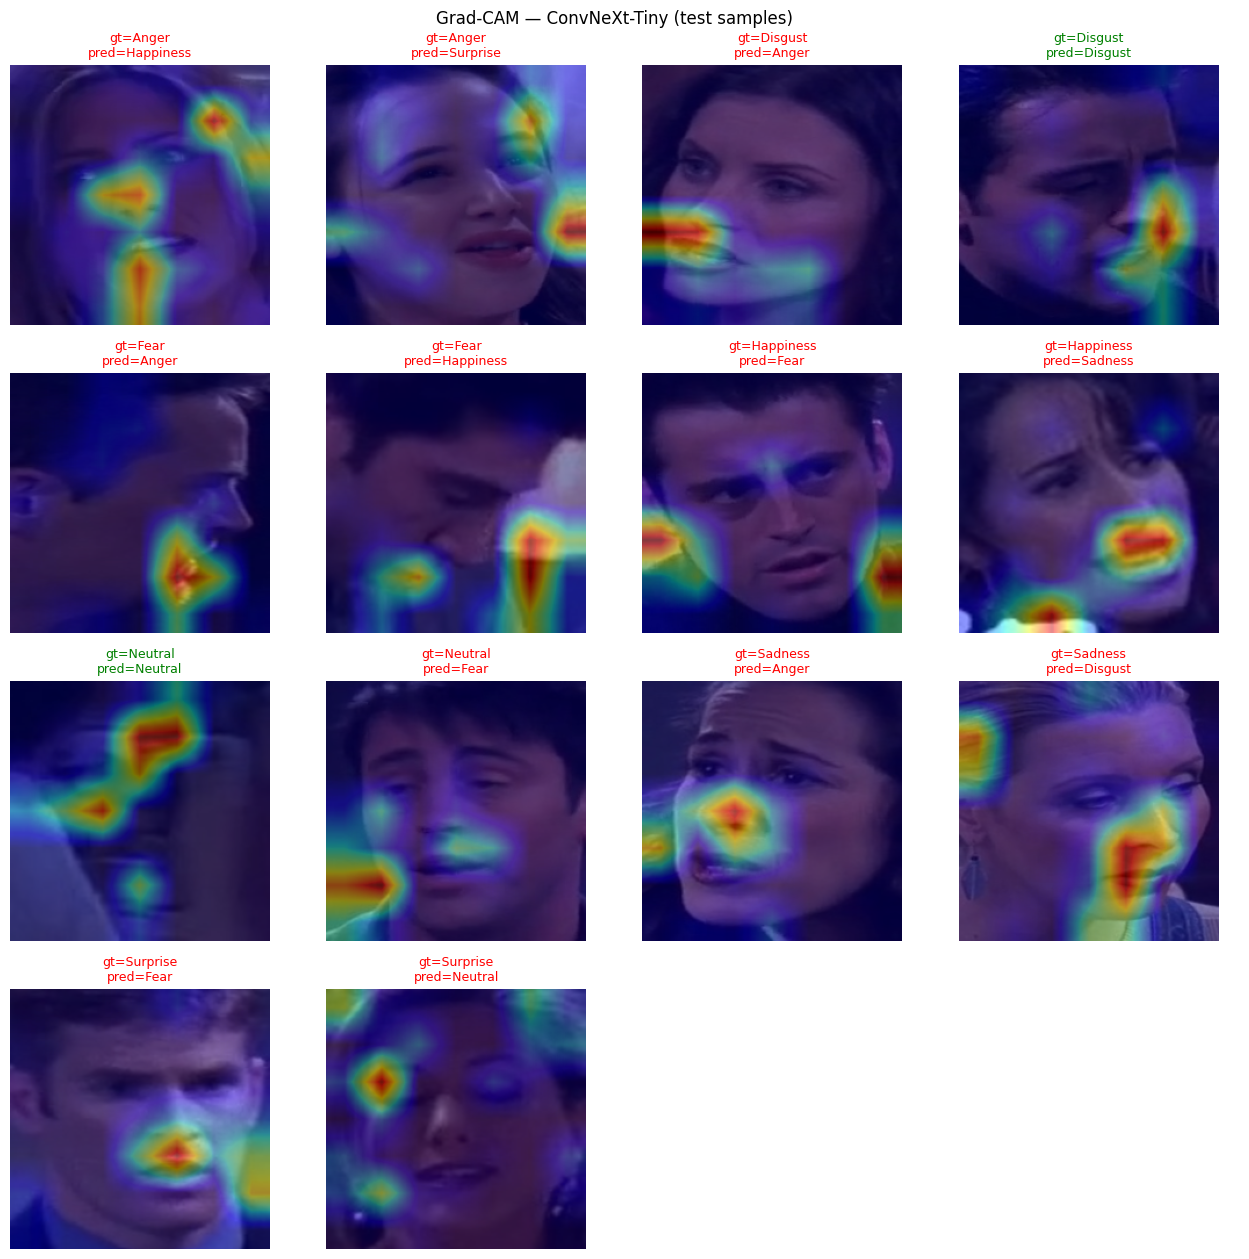

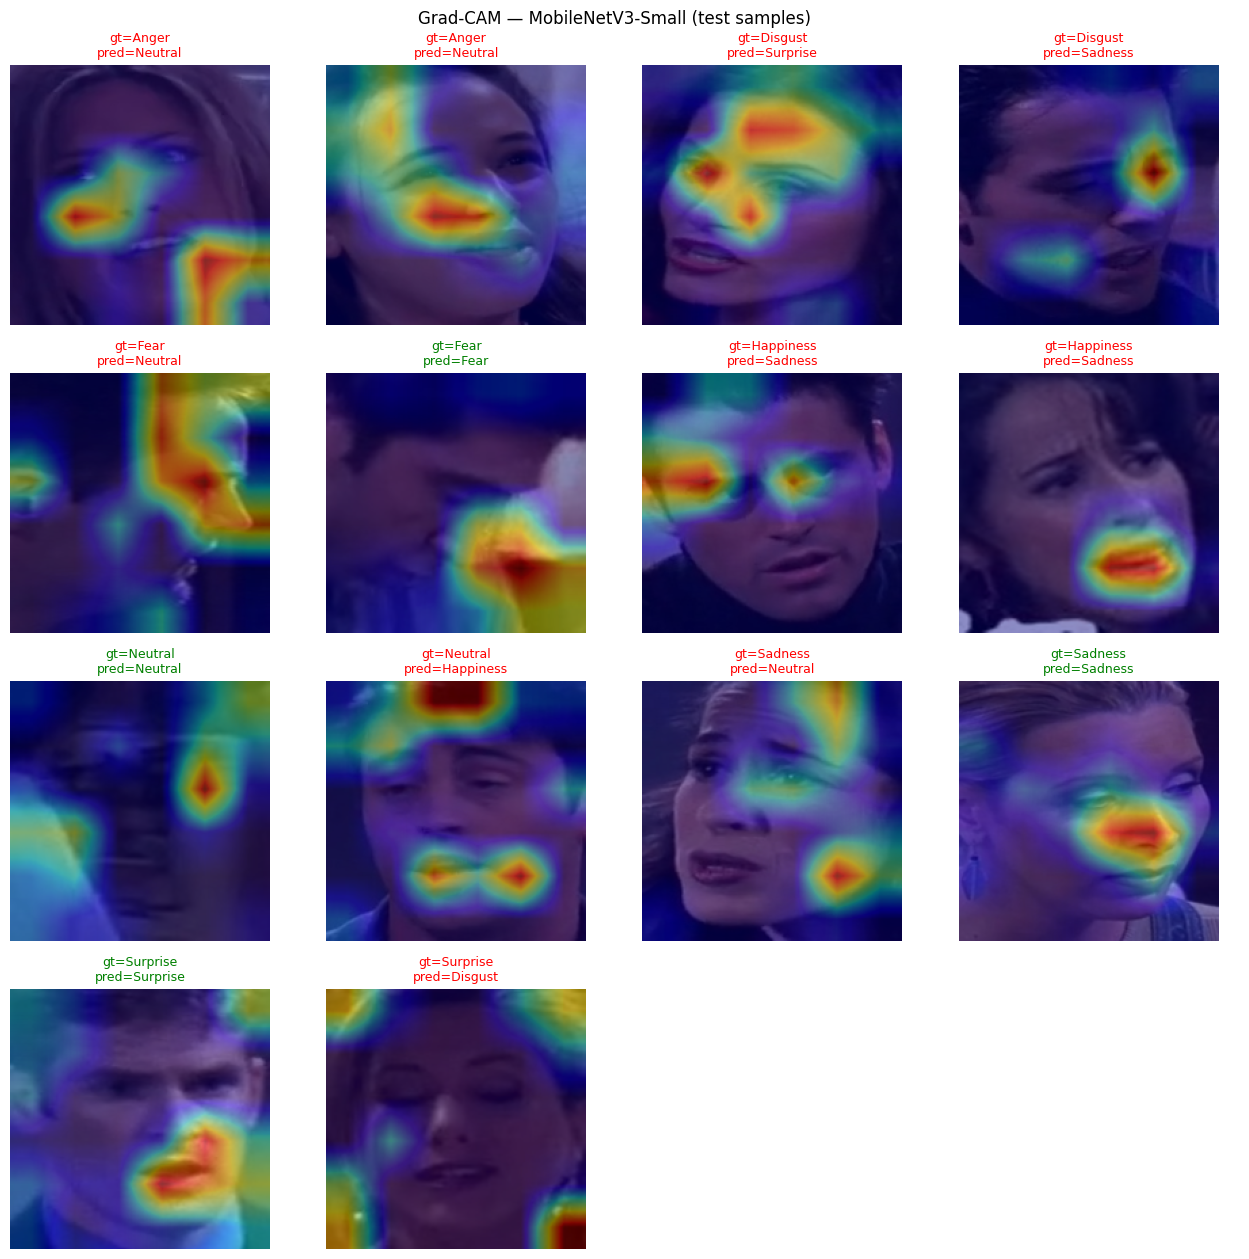

In [31]:
# Same samples for both models so the XAI comparison is apples-to-apples.
samples = pick_samples(df_test, n_per_class=2, seed=SEED)
print(f"Grad-CAM on {len(samples)} test samples.")

run_gradcam_grid(model_big_best, CFG_BIG, samples,
                 "Grad-CAM — ConvNeXt-Tiny (test samples)",
                 EXPERIMENTS_DIR / "gradcam_convnext_tiny.png")

run_gradcam_grid(model_small_best, CFG_SMALL, samples,
                 "Grad-CAM — MobileNetV3-Small (test samples)",
                 EXPERIMENTS_DIR / "gradcam_mobilenetv3_small.png")

## 13. EcoAI — side-by-side comparison

This is the table to pull into the thesis: size, compute, training time, inference
throughput, and (if CodeCarbon ran) real energy and CO2.

In [32]:
def ecoai_summary(model: nn.Module, cfg: TrainConfig, run_info: Dict,
                  test_loader: DataLoader, emissions: Optional[Dict]):
    model = model.to(DEVICE)
    params = count_params(model)
    flops = estimate_flops(model, cfg.img_size)
    throughput = measure_inference_throughput(model, test_loader)
    return {
        "params":              params,
        "params_M":            params / 1e6,
        "flops":               flops,
        "gflops":              (flops / 1e9) if flops is not None else None,
        "img_size":            cfg.img_size,
        "avg_epoch_time_s":    run_info["avg_epoch_time_s"],
        "total_train_time_min": run_info["total_train_time_s"] / 60.0,
        "inference_imgs_per_s": throughput,
        "codecarbon":          emissions,
    }

big_eco   = ecoai_summary(model_big_best,   CFG_BIG,   big_run,   dl_test_big, big_emissions)
small_eco = ecoai_summary(model_small_best, CFG_SMALL, small_run, dl_test_sm, small_emissions)

NameError: name 'big_run' is not defined

In [33]:
def fmt(v, nd=3):
    if v is None: return "-"
    if isinstance(v, float): return f"{v:.{nd}f}"
    if isinstance(v, int):   return f"{v:,}"
    return str(v)

rows = []
for name, eco, test_frame, test_utt, best in [
    ("ConvNeXt-Tiny (big)",      big_eco,   big_test_frame,   big_test_utt,   big_run["best"]),
    ("MobileNetV3-Small (small)",small_eco, small_test_frame, small_test_utt, small_run["best"]),
]:
    rows.append({
        "model": name,
        "params (M)":            fmt(eco["params_M"], 2),
        "GFLOPs":                fmt(eco["gflops"], 3),
        "img_size":              eco["img_size"],
        "avg epoch (s)":         fmt(eco["avg_epoch_time_s"], 1),
        "total train (min)":     fmt(eco["total_train_time_min"], 1),
        "inf. imgs/s":           fmt(eco["inference_imgs_per_s"], 1),
        "energy_kWh":            fmt((eco["codecarbon"] or {}).get("energy_kwh"), 4) if eco["codecarbon"] else "-",
        "CO2_kg":                fmt((eco["codecarbon"] or {}).get("emissions_kg_co2"), 4) if eco["codecarbon"] else "-",
        "best dev F1(w)":        fmt(best["f1_weighted"], 4),
        "test frame F1(w)":      fmt(test_frame["f1_weighted"], 4),
        "test utt F1(w)":        fmt(test_utt["f1_weighted"], 4),
        "test utt acc":          fmt(test_utt["accuracy"], 4),
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(EXPERIMENTS_DIR / "ecoai_summary.csv", index=False)
summary_df

NameError: name 'big_eco' is not defined

In [34]:
# Persist a JSON too — useful if you want to re-load these numbers later for the thesis.
summary_json = {
    "big":   {"eco": big_eco,   "test_frame": {k: float(big_test_frame[k])
                                               for k in ["accuracy","f1_weighted","f1_macro"]},
              "test_utt":   {k: float(big_test_utt[k])
                             for k in ["accuracy","f1_weighted","f1_macro"]},
              "best_dev":   big_run["best"]},
    "small": {"eco": small_eco, "test_frame": {k: float(small_test_frame[k])
                                               for k in ["accuracy","f1_weighted","f1_macro"]},
              "test_utt":   {k: float(small_test_utt[k])
                             for k in ["accuracy","f1_weighted","f1_macro"]},
              "best_dev":   small_run["best"]},
}
with open(EXPERIMENTS_DIR / "ecoai_summary.json", "w") as f:
    # Custom encoder — dataclass / numpy-friendly.
    def default(o):
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (np.integer,)):  return int(o)
        if isinstance(o, np.ndarray):     return o.tolist()
        return str(o)
    json.dump(summary_json, f, indent=2, default=default)
print("Saved:", EXPERIMENTS_DIR / "ecoai_summary.csv")
print("Saved:", EXPERIMENTS_DIR / "ecoai_summary.json")

NameError: name 'big_eco' is not defined

## 14. Notes

* **Best checkpoints:**
  * `Models/best_image_convnext_tiny.pth` (big)
  * `Models/best_image_mobilenetv3_small.pth` (small)
* **Experiment artefacts** (CSV + JSON + PNGs for curves / confusion / Grad-CAM):
  `experiments/image_unimodal/`
* Weighted F1 drives best-checkpoint selection (better than accuracy on MELD because the
  dataset is heavily skewed to *Neutral*).
* If you later regenerate the face crops (better detector, higher resolution, filtered by
  `pred_prob` too), the only thing that should need updating here is `DATA_ROOT` / the
  metadata CSVs — the training pipeline is data-agnostic.